In [1]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
from scoring_subtask_2 import compute_evidence_scores, get_leaderboard, load_key

tree = ET.parse("./v1.4/dev/archehr-qa.xml")
root = tree.getroot()

key_map = load_key("./v1.4/dev/archehr-qa_key.json")

In [2]:
data = []
for case in root.findall("case"):
    case_id = case.get('id')
    question = case.findtext("clinician_question", default="").strip()
    sentences = [
        {
            'sentence_id': sentence.get('id'),
            'text': sentence.text.strip()
        }
        for sentence in case.find("note_excerpt_sentences")
    ]
    item = {
        'case_id': case_id,
        'question': question,
        'sentences': sentences
    }
    data.append(item)

In [3]:
from sentence_transformers import SentenceTransformer

# Load the model
model = SentenceTransformer("Qwen/Qwen3-Embedding-8B", device='mps')

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [4]:
from tqdm.notebook import tqdm

pre_submission = []
for c in tqdm(data):
    case_id = c['case_id']
    query = c['question']
    documents = [i['text'] for i in c['sentences']]
    sentence_ids = [i['sentence_id'] for i in c['sentences']]
    
    query_embedding = model.encode(query, prompt_name="query")
    document_embeddings = model.encode(documents)
    
    scores = model.similarity(query_embedding, document_embeddings).tolist()[0]
    scores_with_ids = [{'id': x, 'score': y} for x, y in zip(sentence_ids, scores)]
    
    pre_submission.append({'case_id': case_id, 'scores': scores_with_ids})

  0%|          | 0/20 [00:00<?, ?it/s]

In [5]:
import numpy as np

thresholds = np.arange(0,1.05,0.05)
overalls = []

for threshold in thresholds:
    submission = [{'case_id': c['case_id'], 'prediction': [i['id'] for i in c['scores'] if i['score']>threshold]} for c in pre_submission]
    scores = compute_evidence_scores(submission, key_map)
    leaderboard = get_leaderboard(scores)
    overall = leaderboard['overall_score']
    overalls.append(overall)

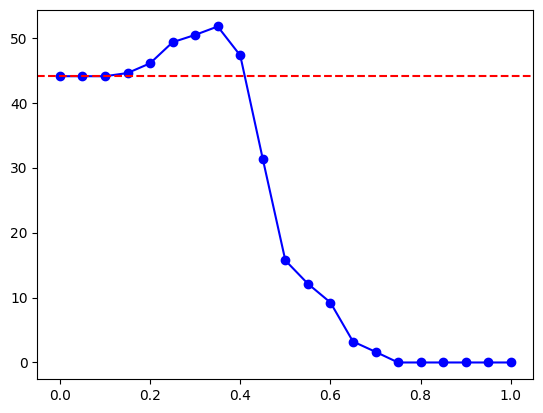

In [6]:
import matplotlib.pyplot as plt

x = thresholds
y = overalls

plt.plot(x, y, marker='o', linestyle='-', color='b')
plt.axhline(44.08, linestyle='--', color='r')
plt.show()

In [7]:
# save thresholds and overalls for plotting later
np.save('./dev_results/qwen_thresholds', thresholds)
np.save('./dev_results/qwen_overalls', overalls)

In [8]:
dict(zip(thresholds.tolist(), overalls))

{0.0: 44.080145719489984,
 0.05: 44.080145719489984,
 0.1: 44.080145719489984,
 0.15000000000000002: 44.56721915285452,
 0.2: 46.06525911708253,
 0.25: 49.31506849315068,
 0.30000000000000004: 50.43988269794721,
 0.35000000000000003: 51.737451737451735,
 0.4: 47.27272727272728,
 0.45: 31.32530120481928,
 0.5: 15.714285714285714,
 0.55: 12.121212121212121,
 0.6000000000000001: 9.230769230769234,
 0.65: 3.225806451612903,
 0.7000000000000001: 1.639344262295082,
 0.75: 0.0,
 0.8: 0.0,
 0.8500000000000001: 0.0,
 0.9: 0.0,
 0.9500000000000001: 0.0,
 1.0: 0.0}

In [9]:
submission = [{'case_id': c['case_id'], 'prediction': [i['id'] for i in c['scores'] if i['score']>0.35]} for c in pre_submission]
scores = compute_evidence_scores(submission, key_map)
leaderboard = get_leaderboard(scores)

In [10]:
leaderboard

{'strict_macro_precision': np.float64(48.8764927023441),
 'strict_macro_recall': np.float64(52.610209235209226),
 'strict_macro_f1': np.float64(45.34708839547549),
 'strict_micro_precision': 48.55072463768116,
 'strict_micro_recall': 55.371900826446286,
 'strict_micro_f1': 51.737451737451735,
 'lenient_macro_precision': np.float64(52.55555555555556),
 'lenient_macro_recall': np.float64(52.610209235209226),
 'lenient_macro_f1': np.float64(47.93309497943364),
 'lenient_micro_precision': 54.47154471544715,
 'lenient_micro_recall': 55.371900826446286,
 'lenient_micro_f1': 54.91803278688525,
 'overall_score': 51.737451737451735}

In [20]:
all_scores = [s['score'] for c in pre_submission for s in c['scores']]

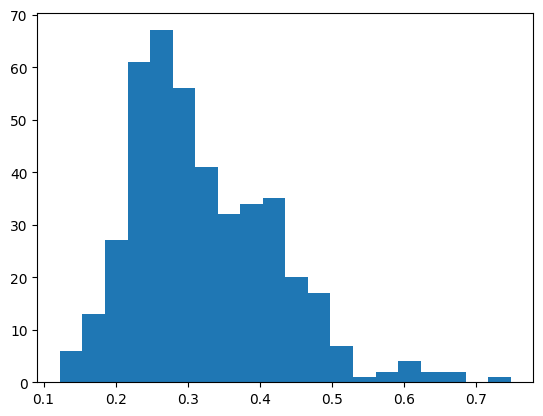

In [22]:
plt.hist(all_scores, bins=20)
plt.show()

In [1]:
# SUBMISSION

In [2]:
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt

tree = ET.parse("./v1.4/test-2026/archehr-qa.xml")
root = tree.getroot()

In [3]:
data = []
for case in root.findall("case"):
    case_id = case.get('id')
    question = case.findtext("clinician_question", default="").strip()
    sentences = [
        {
            'sentence_id': sentence.get('id'),
            'text': sentence.text.strip()
        }
        for sentence in case.find("note_excerpt_sentences")
    ]
    item = {
        'case_id': case_id,
        'question': question,
        'sentences': sentences
    }
    data.append(item)

In [5]:
from sentence_transformers import SentenceTransformer

# Load the model
model = SentenceTransformer("Qwen/Qwen3-Embedding-8B", device='mps')

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

In [6]:
from tqdm.notebook import tqdm

pre_submission = []
for c in tqdm(data):
    case_id = c['case_id']
    query = c['question']
    documents = [i['text'] for i in c['sentences']]
    sentence_ids = [i['sentence_id'] for i in c['sentences']]
    
    query_embedding = model.encode(query, prompt_name="query")
    document_embeddings = model.encode(documents)
    
    scores = model.similarity(query_embedding, document_embeddings).tolist()[0]
    scores_with_ids = [{'id': x, 'score': y} for x, y in zip(sentence_ids, scores)]
    
    pre_submission.append({'case_id': case_id, 'scores': scores_with_ids})

  0%|          | 0/47 [00:00<?, ?it/s]

In [7]:
submission = [{'case_id': c['case_id'], 'prediction': [i['id'] for i in c['scores'] if i['score']>0.35]} for c in pre_submission]

In [10]:
import json

with open("./qwen_baseline/submission.json", 'w') as f:
    json.dump(submission, f)

# Unified Plot

In [1]:
import numpy as np

In [2]:
thresholds = np.load('./dev_results/qwen_thresholds.npy', allow_pickle=True)
thresholds2 = np.load('./dev_results/medcpt_thresholds.npy', allow_pickle=True)
overalls = np.load('./dev_results/qwen_overalls.npy', allow_pickle=True)
overalls2 = np.load('./dev_results/medcpt_overalls.npy', allow_pickle=True)

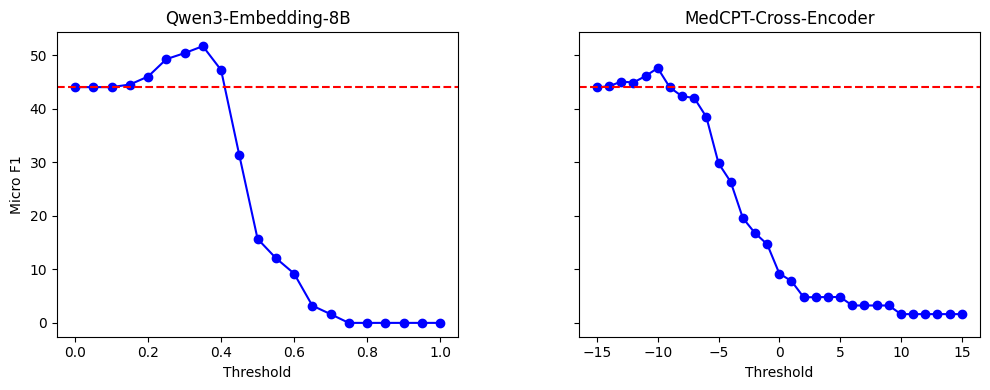

In [9]:
import matplotlib.pyplot as plt

# First dataset
x1 = thresholds
y1 = overalls

# Second dataset
x2 = thresholds2
y2 = overalls2

fig, axes = plt.subplots(1, 2, sharey=True, figsize=(10, 4))

# Plot 1
axes[0].plot(x1, y1, marker='o', linestyle='-', color='b')
axes[0].axhline(44.08, linestyle='--', color='r')
axes[0].set_title("Qwen3-Embedding-8B")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Micro F1")

# Plot 2
axes[1].plot(x2, y2, marker='o', linestyle='-', color='b')
axes[1].axhline(44.08, linestyle='--', color='r')
axes[1].set_title("MedCPT-Cross-Encoder")
axes[1].set_xlabel("Threshold")

plt.tight_layout()
fig.subplots_adjust(wspace=0.3)  # increase horizontal space
plt.savefig('image.png')
plt.show()